In [1]:
# Special Studies: Computer Vision (CSE 40535)
# Practical 03: geometrical transformation, keypoints and panorama stitching
# University of Notre Dame
# ____________________________________________________________________________
# Adam Czajka, Siamul Khan, Thomas Summe, Gelei Xu, Walter Scheirer, 2019-2025

##Let's start with installation of necessary packages we will use today##

In [2]:
import numpy as np
import math
import cv2

try:
    from google.colab.patches import cv2_imshow
except ImportError:
    import matplotlib.pyplot as plt
    def cv2_imshow(img):
        plt.figure(figsize=(14, 7))
        if len(img.shape) == 3:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        else:
            plt.imshow(img, cmap='gray')
        plt.axis('off')
        plt.show()

# print(cv2.__version__)

**If you have your images in your Google drive, uncomment the lines below and mount it**

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

##The codes in this cell create the SIFT feature finder object (just run it)##

---



In [4]:
sift = cv2.SIFT_create(contrastThreshold=0.04, edgeThreshold=10, sigma=1.6)

# Opencv does not automatically handle dimensions of warped images, if the warped results falls outside the image window it will be cutoff
# Thus, here we define a function that will take in the images and the transformation matrices and add appropriate translations to the transformation
# matrices and also provide the panorama dimensions
def getPanoDimsTransl_twoImages(im_left, im_middle, tforms, im_keys):
    border_points = {}
    border_points['left'] = np.float32([[0, 0, 1], [0, im_left.shape[0], 1], \
                            [im_left.shape[1], 0, 1], [im_left.shape[1], im_left.shape[0], 1]])
    border_points['middle'] = np.float32([(0, 0, 1), (0, im_middle.shape[0], 1), \
                            [im_middle.shape[1], 0, 1], [im_middle.shape[1], im_middle.shape[0], 1]])

    # First, we are using transformation matrices to find the warped image border points for each image.
    # We are then using these transformed border points to find the panorama width and height
    warped_border_x = {}
    warped_border_y = {}
    for im_key in im_keys:
        tformed_points = tforms[im_key] @ np.transpose(border_points[im_key])  # matrix multiplication (also works with np.matmul)
        tformed_points = np.transpose(tformed_points)
        warped_border_x[im_key] = list(tformed_points[:, 0]/tformed_points[:,2])
        warped_border_y[im_key] = list(tformed_points[:, 1]/tformed_points[:,2])

    max_widths = {}
    max_heights = {}
    for im_key in im_keys:
        max_widths[im_key] = math.ceil(max(warped_border_x[im_key]) - min(warped_border_x[im_key])) + 1
        max_heights[im_key] = math.ceil(max(warped_border_y[im_key]) - min(warped_border_y[im_key])) + 1

    panorama_width = 0
    panorama_height = 0
    for im_key in im_keys:
        panorama_width += max_widths[im_key]
        if panorama_height < max_heights[im_key]:
            panorama_height = max_heights[im_key]

    # track negative values of x in left image to determine positive translation in x
    # track negative values of y in all images to determine positive translation in y
    x_translation = math.ceil(-min(warped_border_x['left'] + warped_border_x['middle'] ))
    y_translation = math.ceil(-min(warped_border_y['left'] + warped_border_y['middle'] ))

    trans_mat = np.float32([[1, 0, x_translation], [0, 1, y_translation],[0, 0, 1]])

    for im_key in im_keys:
        tforms[im_key] = trans_mat @ tforms[im_key]

    return (panorama_width, panorama_height), tforms

def getPanoDimsTransl_threeImages(im_left, im_middle, im_right, tforms, im_keys):
    border_points = {}
    border_points['left'] = np.float32([[0, 0, 1], [0, im_left.shape[0], 1], \
                            [im_left.shape[1], 0, 1], [im_left.shape[1], im_left.shape[0], 1]])
    border_points['middle'] = np.float32([(0, 0, 1), (0, im_middle.shape[0], 1), \
                            [im_middle.shape[1], 0, 1], [im_middle.shape[1], im_middle.shape[0], 1]])
    border_points['right'] = np.float32([[0, 0, 1], [0, im_right.shape[0], 1], \
                            [im_right.shape[1], 0, 1], [im_right.shape[1], im_right.shape[0], 1]])

    # First, we are using transformation matrices to find the warped image border points for each image.
    # We are then using these transformed border points to find the panorama width and height
    warped_border_x = {}
    warped_border_y = {}
    required_x_translation = 0
    required_y_translation = 0
    for im_key in im_keys:
        tformed_points = tforms[im_key] @ np.transpose(border_points[im_key])  # matrix multiplication (also works with np.matmul)
        tformed_points = np.transpose(tformed_points)
        warped_border_x[im_key] = list(tformed_points[:, 0]/tformed_points[:,2])
        warped_border_y[im_key] = list(tformed_points[:, 1]/tformed_points[:,2])

    max_widths = {}
    max_heights = {}
    for im_key in im_keys:
        max_widths[im_key] = math.ceil(max(warped_border_x[im_key]) - min(warped_border_x[im_key])) + 1
        max_heights[im_key] = math.ceil(max(warped_border_y[im_key]) - min(warped_border_y[im_key])) + 1

    panorama_width = 0
    panorama_height = 0
    for im_key in im_keys:
        panorama_width += max_widths[im_key]
        if panorama_height < max_heights[im_key]:
            panorama_height = max_heights[im_key]

    # track negative values of x in left image to determine positive translation in x
    # track negative values of y in all images to determine positive translation in y
    x_translation = math.ceil(-min(warped_border_x['left'] + warped_border_x['middle'] + warped_border_x['right']))
    y_translation = math.ceil(-min(warped_border_y['left'] + warped_border_y['middle'] + warped_border_y['right']))

    trans_mat = np.float32([[1, 0, x_translation], [0, 1, y_translation],[0, 0, 1]])

    for im_key in im_keys:
        tforms[im_key] = trans_mat @ tforms[im_key]

    return (panorama_width, panorama_height), tforms

# Interpolation can cause noise at the borders, using masks to remove some pixels from the border (not required if you use INTER_NEAREST as flags)
def getErodedWarpedIm_twoImages(warped_im_left, warped_im_middle):
    kernel = np.ones((3, 3),np.uint8)
    erosion_mask_left = cv2.erode(cv2.warpPerspective(np.ones(im_left.shape[:2], dtype="uint8") * 255, tforms['left'], (panorama_width, panorama_height), flags=cv2.INTER_NEAREST), kernel)
    warped_im_left = cv2.bitwise_and(warped_im_left, warped_im_left, mask=erosion_mask_left)
    erosion_mask_middle = cv2.erode(cv2.warpPerspective(np.ones(im_middle.shape[:2], dtype="uint8") * 255, tforms['middle'], (panorama_width, panorama_height), flags=cv2.INTER_NEAREST), kernel)
    warped_im_middle = cv2.bitwise_and(warped_im_middle, warped_im_middle, mask=erosion_mask_middle)
    return warped_im_left, warped_im_middle

def getErodedWarpedIm_threeImages(warped_im_left, warped_im_middle, warped_im_right):
    kernel = np.ones((3, 3),np.uint8)
    erosion_mask_left = cv2.erode(cv2.warpPerspective(np.ones(im_left.shape[:2], dtype="uint8") * 255, tforms['left'], (panorama_width, panorama_height), flags=cv2.INTER_NEAREST), kernel)
    warped_im_left = cv2.bitwise_and(warped_im_left, warped_im_left, mask=erosion_mask_left)
    erosion_mask_middle = cv2.erode(cv2.warpPerspective(np.ones(im_middle.shape[:2], dtype="uint8") * 255, tforms['middle'], (panorama_width, panorama_height), flags=cv2.INTER_NEAREST), kernel)
    warped_im_middle = cv2.bitwise_and(warped_im_middle, warped_im_middle, mask=erosion_mask_middle)
    erosion_mask_right = cv2.erode(cv2.warpPerspective(np.ones(im_right.shape[:2], dtype="uint8") * 255, tforms['right'], (panorama_width, panorama_height), flags=cv2.INTER_NEAREST), kernel)
    warped_im_right = cv2.bitwise_and(warped_im_right, warped_im_right, mask=erosion_mask_right)
    return warped_im_left, warped_im_middle, warped_im_right

##Your tasks for today start here##

In [5]:
#############################################################################################
# *** TASKS 0 and 1: read your images here, you may adjust the image path
#############################################################################################
im_left   = cv2.imread('nd1.jpg')
im_middle = cv2.imread('nd2.jpg')
im_right  = cv2.imread('nd3.jpg')  # *** TASK 1: third image

**Since we have multiple images to be stitched, we we use a dictionary of transforms (tforms):**

In [6]:
tforms = {}
im_keys = ['left', 'middle', 'right']  # *** TASK 1: added 'right'


**Now let's find SIFT keypoints and SIFT descriptors for all our images:**

In [7]:
# Find SIFT keypoints and descriptors for the left image
grayImage_left = cv2.cvtColor(im_left, cv2.COLOR_BGR2GRAY)
keypoints_left, descriptors_left = sift.detectAndCompute(grayImage_left, None)

# Find SIFT keypoints and descriptors for the middle image
grayImage_middle = cv2.cvtColor(im_middle, cv2.COLOR_BGR2GRAY)
keypoints_middle, descriptors_middle = sift.detectAndCompute(grayImage_middle, None)

# *** TASK 1: Find SIFT keypoints and descriptors for the RIGHT image
grayImage_right = cv2.cvtColor(im_right, cv2.COLOR_BGR2GRAY)
keypoints_right, descriptors_right = sift.detectAndCompute(grayImage_right, None)

**Now we need to find pairs of matching keypoints between adjacent images:**

In [8]:
# Match keypoints between the left and the middle image using SIFT descriptors
bf = cv2.BFMatcher(crossCheck=True)
matches_lm = bf.match(descriptors_left, descriptors_middle)

# *** TASK 1: Match keypoints between the middle and the RIGHT image
matches_mr = bf.match(descriptors_middle, descriptors_right)


**You can display top 20 matches, if you wanted. Do these matching keypoint pairs make sense?**

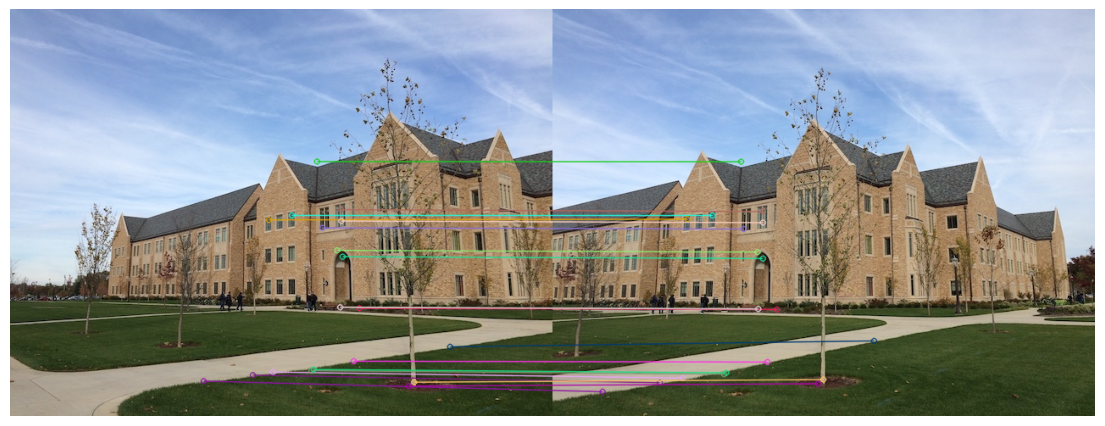

In [9]:
matches_lm_sorted = sorted(matches_lm, key = lambda x:x.distance)
match_shape = (im_left.shape[0]+im_middle.shape[0], im_left.shape[1]+im_middle.shape[1])
match_img = np.zeros(match_shape)
match_img = cv2.drawMatches(im_left, keypoints_left, im_middle, keypoints_middle, matches_lm_sorted[:20], match_img, flags=2)
cv2_imshow(match_img)

**To calculate transformation matrices (tforms), we need at least 4 points (from the matching pairs) for each image separately. The code below does that:**

In [10]:
# Find matching points between the left and the middle image from the DMatcher objects
if len(matches_lm) >= 4:
    left_points   = np.float32([ keypoints_left[m.queryIdx].pt   for m in matches_lm ]).reshape(-1,1,2)
    middle_points = np.float32([ keypoints_middle[m.trainIdx].pt for m in matches_lm ]).reshape(-1,1,2)
else:
    print('Images are too different, less than 4 keypoint matches found.')
    exit()

# *** TASK 1: Find matching points between the middle and the RIGHT image
if len(matches_mr) >= 4:
    middle_points_new = np.float32([ keypoints_middle[m.queryIdx].pt for m in matches_mr ]).reshape(-1,1,2)
    right_points      = np.float32([ keypoints_right[m.trainIdx].pt  for m in matches_mr ]).reshape(-1,1,2)
else:
    print('Middle and right images are too different, less than 4 keypoint matches found.')
    exit()


**It's time to define the transformation matrices (tforms) for all images:**

In [11]:
# For the left image, the transformation matrix is an identity matrix:
tforms['left'] = np.identity(3)

# For the middle image, the projective transformation matrix is calculated with the use
# of the corresponding (matching) SIFT keypoints between the left and the middle image:
H, masked = cv2.findHomography(middle_points, left_points, cv2.RANSAC, 5.0)
tforms['middle'] = H

# *** TASK 1: Projective transformation for the RIGHT image
# H2 maps right image coordinates to middle image coordinates
H2, masked2 = cv2.findHomography(right_points, middle_points_new, cv2.RANSAC, 5.0)
# Chain: right -> middle -> left  (tforms['middle'] maps middle -> left)
tforms['right'] = tforms['middle'] @ H2


**Now we are ready to prepare the warped images based on our transformation matrices (tforms):**

In [12]:
# *** TASK 1: use getPanoDimsTransl_threeImages() instead of getPanoDimsTransl_twoImages()
(panorama_width, panorama_height), tforms = getPanoDimsTransl_threeImages(im_left, im_middle, im_right, tforms, im_keys)

# Warp all three images using their projective transformation matrices
warped_im_left   = cv2.warpPerspective(im_left,   tforms['left'],   (panorama_width, panorama_height))
warped_im_middle = cv2.warpPerspective(im_middle,  tforms['middle'], (panorama_width, panorama_height))
warped_im_right  = cv2.warpPerspective(im_right,   tforms['right'],  (panorama_width, panorama_height))

# *** TASK 1: use getErodedWarpedIm_threeImages() instead of getErodedWarpedIm_twoImages()
warped_im_left, warped_im_middle, warped_im_right = getErodedWarpedIm_threeImages(
    warped_im_left, warped_im_middle, warped_im_right)


**Put all images together into the panorama:**

In [13]:
stitched_im = warped_im_left
np.copyto(stitched_im, warped_im_middle, where=(stitched_im == 0))

# *** TASK 1: add the right image to the panorama
np.copyto(stitched_im, warped_im_right, where=(stitched_im == 0))


**And here we go! Display your stitched panorama:**

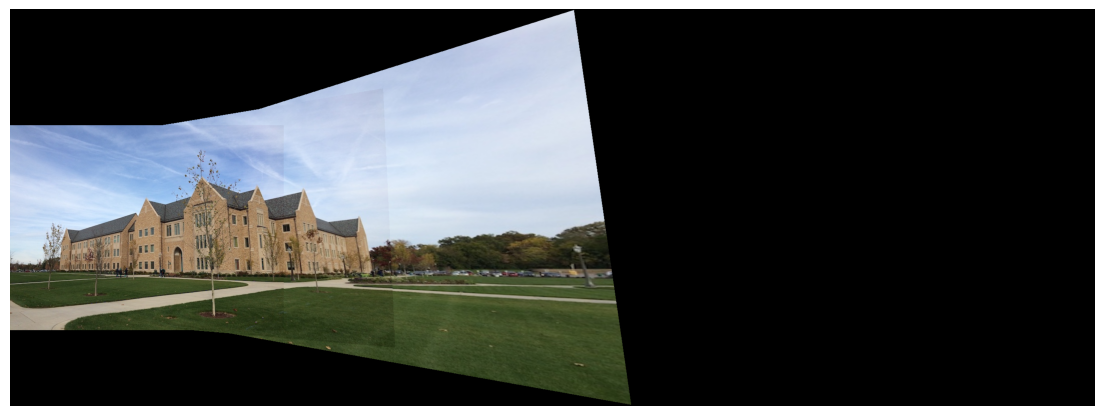

In [14]:
cv2_imshow(stitched_im)

**Task 2: Make the MIDDLE image the reference (3-line change)**

The tip from the slides: only `tforms['left']`, `tforms['middle']`, `tforms['right']` change.
- `tforms['middle'] = I` (middle is now the reference)
- `tforms['left'] = H⁻¹` (H mapped middle→left, so H⁻¹ maps left→middle)
- `tforms['right'] = H2` (H2 already maps right→middle, no chain needed)

Task 2 — middle as reference panorama:


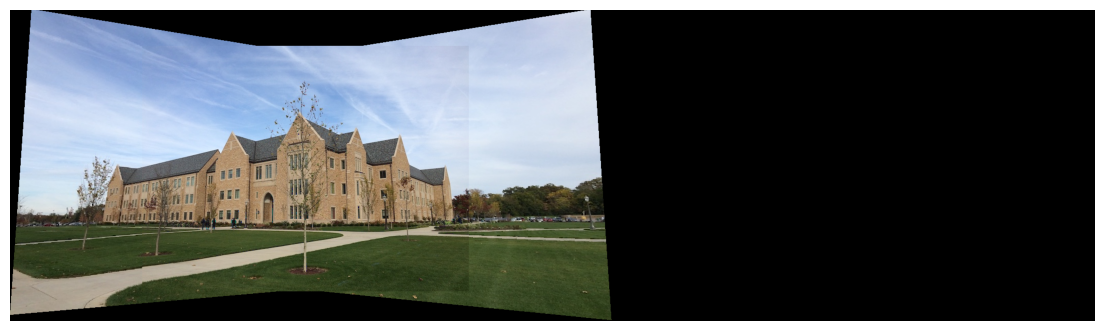

In [15]:
##############################################################################
# Task 2: Change reference to MIDDLE image
# Only 3 lines differ from Task 1's tforms definition:
##############################################################################
tforms_t2 = {}
tforms_t2['middle'] = np.identity(3)       # ← was H  (middle is now reference)
tforms_t2['left']   = np.linalg.inv(H)     # ← was identity  (H mapped middle→left, inv maps left→middle)
tforms_t2['right']  = H2                   # ← was tforms['middle'] @ H2  (H2 maps right→middle directly)

# Rerun the full panorama pipeline with the new tforms
(pano_w_t2, pano_h_t2), tforms_t2 = getPanoDimsTransl_threeImages(
    im_left, im_middle, im_right, tforms_t2, im_keys)

# INTER_NEAREST avoids border interpolation artifacts (no erosion mask needed)
warped_left_t2  = cv2.warpPerspective(im_left,   tforms_t2['left'],   (pano_w_t2, pano_h_t2), flags=cv2.INTER_NEAREST)
warped_mid_t2   = cv2.warpPerspective(im_middle,  tforms_t2['middle'], (pano_w_t2, pano_h_t2), flags=cv2.INTER_NEAREST)
warped_right_t2 = cv2.warpPerspective(im_right,   tforms_t2['right'],  (pano_w_t2, pano_h_t2), flags=cv2.INTER_NEAREST)

# Stitch (middle first since it is the reference and fills the centre cleanly)
stitched_im_t2 = warped_mid_t2.copy()
np.copyto(stitched_im_t2, warped_left_t2,  where=(stitched_im_t2 == 0))
np.copyto(stitched_im_t2, warped_right_t2, where=(stitched_im_t2 == 0))

print('Task 2 — middle as reference panorama:')
cv2_imshow(stitched_im_t2)


  Corner TL: (118, 85)
  Corner TR: (967, 98)
  Corner BR: (1000, 505)
  Corner BL: (59, 498)
All 4 corners selected — press any key to continue.
Task 3 — de-warped panorama:


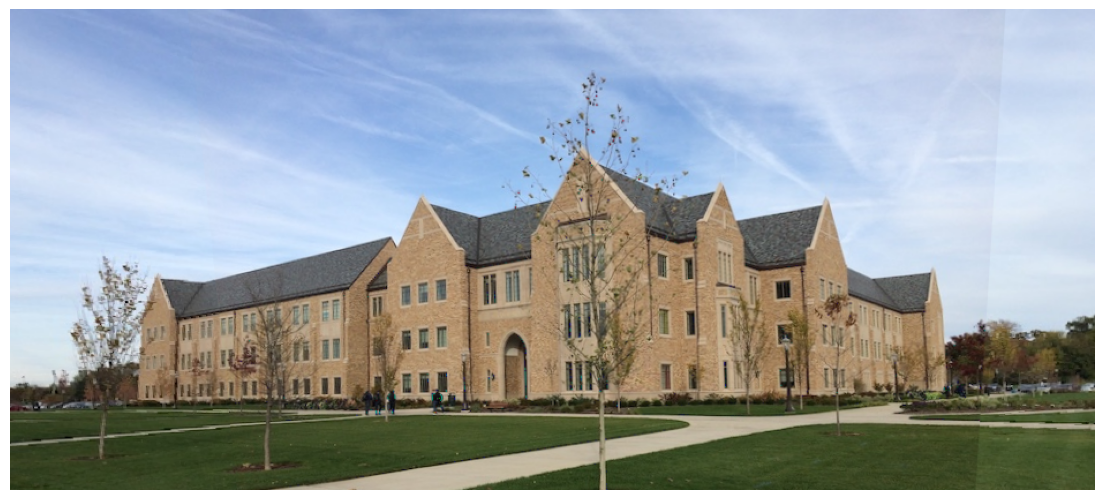

In [16]:
##############################################################################
# Task 3: De-warp the panorama using HW06's projective-transform approach.
#
# HW06 used roiPoly (an OpenCV GUI) to click 4 corners of the artwork, then
# applied cv2.getPerspectiveTransform + cv2.warpPerspective to flatten it.
# Here we do exactly the same on the stitched panorama using an OpenCV window.
#
# Instructions:
#   1. A window opens showing the Task 2 panorama.
#   2. Click the 4 corners of the rectangular content CLOCKWISE:
#         top-left → top-right → bottom-right → bottom-left
#   3. Press any key to apply the transform.
##############################################################################

src_pts_t3 = []

def on_click_t3(event, x, y, flags, display_img):
    if event == cv2.EVENT_LBUTTONDOWN and len(src_pts_t3) < 4:
        src_pts_t3.append([x, y])
        label = ['TL', 'TR', 'BR', 'BL'][len(src_pts_t3) - 1]
        print(f'  Corner {label}: ({x}, {y})')
        cv2.circle(display_img, (x, y), 10, (0, 255, 0), -1)
        cv2.putText(display_img, label, (x + 14, y - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
        cv2.imshow(win_t3, display_img)
        if len(src_pts_t3) == 4:
            print('All 4 corners selected — press any key to continue.')

display_t3 = stitched_im_t2.copy()
cv2.putText(display_t3,
    'Click TL -> TR -> BR -> BL  |  press any key when done',
    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 200, 255), 2)

win_t3 = 'Task 3 — select 4 corners of the rectangular content'
cv2.namedWindow(win_t3, cv2.WINDOW_NORMAL)
cv2.resizeWindow(win_t3, 1400, 500)
cv2.setMouseCallback(win_t3, on_click_t3, display_t3)
cv2.imshow(win_t3, display_t3)
cv2.waitKey(0)
cv2.destroyAllWindows()

# --- same projective transform as HW06 ---
src = np.float32(src_pts_t3)   # 4 selected corners (like roi.points in HW06)

# Output rectangle dimensions inferred from the selected quadrilateral
out_w = max(int(np.linalg.norm(src[1] - src[0])),   # top edge length
            int(np.linalg.norm(src[2] - src[3])))    # bottom edge length
out_h = max(int(np.linalg.norm(src[3] - src[0])),   # left edge length
            int(np.linalg.norm(src[2] - src[1])))    # right edge length

dst = np.float32([[0, 0], [out_w - 1, 0], [out_w - 1, out_h - 1], [0, out_h - 1]])

H_dewarp = cv2.getPerspectiveTransform(src, dst)
stitched_dewarped = cv2.warpPerspective(stitched_im_t2, H_dewarp, (out_w, out_h))

print('Task 3 — de-warped panorama:')
cv2_imshow(stitched_dewarped)
